# 🎨 Análise do Acervo Portinari
Notebook para explorar os metadados extraídos pelo scraper.

## 1. Carregando o JSON

In [11]:
import json
import pandas as pd
from pathlib import Path

# Ajuste o caminho se necessário
caminho = Path('output/obras.json')

with open(caminho, encoding='utf-8') as f:
    obras = json.load(f)

print(f'Total de obras carregadas: {len(obras)}')
print(f'\nExemplo da primeira obra:')
print(json.dumps(obras[0], ensure_ascii=False, indent=2))

Total de obras carregadas: 1826

Exemplo da primeira obra:
{
  "id": "14686",
  "obraUrl": "https://www.portinari.org.br/acervo/obras/14686/autorretrato",
  "titulo": "Autorretrato",
  "codigoFCO": "FCO-1",
  "numeroCR": "CR-4093",
  "dataTexto": "[1957]",
  "imagemUrl": "https://acervo-portinari.s3.sa-east-1.amazonaws.com/ae148e126345286ac5de04554ef7b513.jpeg",
  "descricaoResumida": "Composição nos tons claro de ocres, cinza e azul. Textura espessa com pinceladas largas. Autorretrato de meio-busto do artista, tomando a...",
  "descricaoCompleta": "Composição nos tons claro de ocres, cinza e azul. Textura espessa com pinceladas largas. Autorretrato de meio-busto do artista, tomando a quase totalidade da área da composição, contra fundo ocre. O retratado está 3/4 para a direita, tem rosto arredondado, cabelos penteados para trás, com ligeiro topete na frente, testa larga e sobrancelhas curtas, espessas. Usa óculos com aros finos e lentes redondas, vendo-se através dos vidros desses, ol

## 2. Convertendo para DataFrame (tabela)

In [12]:
df = pd.DataFrame(obras)

# Colunas que têm listas (ex: temas, pessoasRetratadas) precisam de tratamento especial
# Por ora, vamos converter listas para string separada por vírgula
colunas_lista = ['temas', 'pessoasRetratadas']
for col in colunas_lista:
    if col in df.columns:
        df[col] = df[col].apply(
            lambda x: ', '.join(x) if isinstance(x, list) else x
        )

print(f'Shape: {df.shape}  →  {df.shape[0]} linhas × {df.shape[1]} colunas')
print(f'\nColunas disponíveis:')
print(list(df.columns))
df.head()

Shape: (1826, 24)  →  1826 linhas × 24 colunas

Colunas disponíveis:
['id', 'obraUrl', 'titulo', 'codigoFCO', 'numeroCR', 'dataTexto', 'imagemUrl', 'descricaoResumida', 'descricaoCompleta', 'localProducao', 'autoria', 'tipoObra', 'tecnica', 'suporte', 'numeroDN', 'altura', 'largura', 'assinatura', 'inscricaoFamilia', 'inscricaoExposicao', 'dimensoes', 'temas', 'pessoasRetratadas', 'imagemLocal']


,id,obraUrl,titulo,codigoFCO,numeroCR,dataTexto,imagemUrl,descricaoResumida,descricaoCompleta,localProducao,...,numeroDN,altura,largura,assinatura,inscricaoFamilia,inscricaoExposicao,dimensoes,temas,pessoasRetratadas,imagemLocal
0,14686,https://www.portinari.org.br/acervo/obras/1468...,Autorretrato,FCO-1,CR-4093,[1957],https://acervo-portinari.s3.sa-east-1.amazonaw...,"Composição nos tons claro de ocres, cinza e az...","Composição nos tons claro de ocres, cinza e az...",Brasil > São Paulo > Brodowski > Brasil > Rio ...,...,994,"29,5",21,Assinatura estampada na metade inferior à esqu...,"No verso, inscrição de Maria Portinari “ON 994”.",None,"29,5 x 21 cm","Retrato, Autorretrato, Figura Humana, Homem",Candido Portinari,14686_Autorretrato.jpeg
1,14701,https://www.portinari.org.br/acervo/obras/1470...,Autorretrato,FCO-2,CR-967,1939,https://acervo-portinari.s3.sa-east-1.amazonaw...,"Composição nos tons terras, cinzas, preto, ama...","Composição nos tons terras, cinzas, preto, ama...",Brasil > Rio de Janeiro > Rio de Janeiro,...,986,42,35,Sem assinatura,"No verso, inscrição de Maria Portinari “ON 986”.",None,42 x 35 cm,"Retrato, Autorretrato, Figura Humana, Homem",Candido Portinari,14701_Autorretrato.jpeg
2,14715,https://www.portinari.org.br/acervo/obras/1471...,Autorretrato,FCO-3,CR-4094,1957,https://acervo-portinari.s3.sa-east-1.amazonaw...,"Composição nos tons ocres, terras, brancos, az...","Composição nos tons ocres, terras, brancos, az...",Brasil > São Paulo > Brodowski,...,995,54,45,Sem assinatura,"No verso, inscrição de Maria Portinari “ON 995A”.","No verso, inscrição “Nº 20 Milão”; etiquetas “...",54 x 45 cm,"Retrato, Autorretrato, Figura Humana, Homem",Candido Portinari,14715_Autorretrato.jpeg
3,14720,https://www.portinari.org.br/acervo/obras/1472...,Meu Pai,FCO-4,CR-4095,1957,https://acervo-portinari.s3.sa-east-1.amazonaw...,"Composição nos tons ocres, terras, verdes, ros...","Composição nos tons ocres, terras, verdes, ros...",Brasil > São Paulo > Brodowski,...,946,"40,5","32,5",Sem assinatura,"No verso, inscrição de Maria Portinari “ON 946”.",None,"40,5 x 32,5 cm","Retrato, Família do artista, Pai, Figura Human...",Baptista Portinari,14720_Meu_Pai.jpeg
4,14726,https://www.portinari.org.br/acervo/obras/1472...,Meu Pai,FCO-5,CR-943,[1938],https://acervo-portinari.s3.sa-east-1.amazonaw...,"Composição nos tons terras, verdes, amarelos, ...","Composição nos tons terras, verdes, amarelos, ...",Brasil > São Paulo > Brodowski,...,409,44,32,Sem assinatura e sem data,"No verso, traços possivelmente feitos pelo art...",None,44 x 32 cm,"Retrato, Família do artista, Pai, Figura Human...",Baptista Portinari,14726_Meu_Pai.jpeg


## 3. Verificando qualidade dos dados

In [13]:
# Quantos campos estão preenchidos em cada coluna?
total = len(df)
preenchimento = (
    df.notna()
    .sum()
    .sort_values(ascending=False)
    .rename('preenchidos')
    .to_frame()
)
preenchimento['%'] = (preenchimento['preenchidos'] / total * 100).round(1)
preenchimento

,preenchidos,%
id,1826,100.0
localProducao,1826,100.0
pessoasRetratadas,1826,100.0
temas,1826,100.0
suporte,1826,100.0
obraUrl,1826,100.0
tipoObra,1826,100.0
autoria,1826,100.0
tecnica,1826,100.0
dataTexto,1826,100.0


## 4. Limpeza e normalização

In [14]:
# Extrai o ano numérico da coluna dataTexto
# Exemplos de entrada: '[1941]', '1957', '[c. 1938]'
import re

def extrair_ano(texto):
    if not isinstance(texto, str):
        return None
    match = re.search(r'\d{4}', texto)
    return int(match.group()) if match else None

df['ano'] = df['dataTexto'].apply(extrair_ano)

# Converte altura e largura para número
for col in ['altura', 'largura']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print('Anos únicos encontrados:')
print(sorted(df['ano'].dropna().unique().tolist()))

Anos únicos encontrados:
[1920.0, 1921.0, 1922.0, 1923.0, 1924.0, 1925.0, 1926.0, 1927.0, 1928.0, 1929.0, 1930.0, 1931.0, 1932.0, 1933.0, 1934.0, 1935.0, 1936.0, 1937.0, 1938.0, 1939.0, 1940.0, 1941.0, 1942.0, 1943.0, 1944.0, 1945.0, 1946.0, 1947.0, 1948.0, 1949.0, 1950.0, 1951.0, 1952.0, 1953.0, 1954.0, 1955.0, 1956.0, 1957.0, 1958.0, 1959.0, 1960.0, 1961.0, 1962.0]


## 5. Buscas e filtros

In [15]:
# ── Filtrar por técnica ───────────────────────────────────────────
oleos = df[df['tecnica'].str.contains('óleo', case=False, na=False)]
print(f'Obras a óleo: {len(oleos)}')

# ── Filtrar por intervalo de anos ────────────────────────────────
decada_40 = df[(df['ano'] >= 1940) & (df['ano'] < 1950)]
print(f'Obras da década de 40: {len(decada_40)}')

# ── Buscar por palavra no título ─────────────────────────────────
retratos = df[df['titulo'].str.contains('Retrato', case=False, na=False)]
print(f'Obras com "Retrato" no título: {len(retratos)}')

# ── Obras sem imagem baixada ─────────────────────────────────────
sem_imagem = df[df['imagemLocal'].isna()]
print(f'Obras sem imagem salva: {len(sem_imagem)}')

retratos[['titulo', 'ano', 'tecnica', 'dimensoes']].head(10)

Obras a óleo: 1421
Obras da década de 40: 612
Obras com "Retrato" no título: 430
Obras sem imagem salva: 19


,titulo,ano,tecnica,dimensoes
0,Autorretrato,1957.0,óleo,"29,5 x 21 cm"
1,Autorretrato,1939.0,óleo com areia,42 x 35 cm
2,Autorretrato,1957.0,óleo,54 x 45 cm
6,Retrato de Dona Dominga e Seu Baptista,1941.0,aquarela,22 x 23 cm
7,Retrato de Maria Torquato,1957.0,óleo,46 x 38 cm
8,Retrato de Maria,1933.0,óleo,"43 x 35,5 cm"
9,Retrato de Maria,1957.0,óleo,"55 x 45,5 cm"
10,Retrato de Maria,1931.0,óleo,"52 x 35,5 cm"
11,Retrato de Maria,1934.0,óleo,41 x 31 cm
12,Retrato de Maria,1932.0,"óleo, nanquim pincel",22 x 12 cm


## 6. Visualizações rápidas

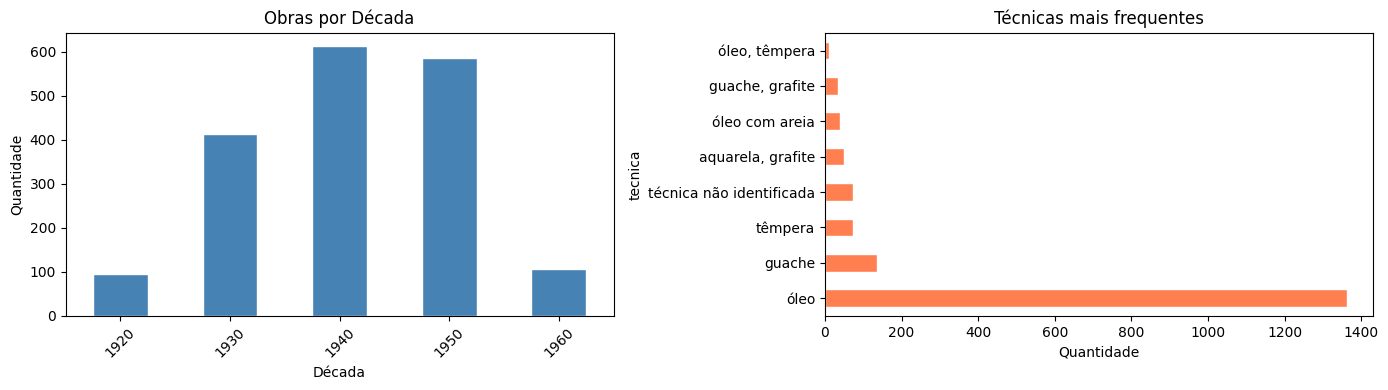

In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Obras por década
df['decada'] = (df['ano'] // 10 * 10).astype('Int64')
contagem_decada = df['decada'].value_counts().sort_index()
contagem_decada.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Obras por Década')
axes[0].set_xlabel('Década')
axes[0].set_ylabel('Quantidade')
axes[0].tick_params(axis='x', rotation=45)

# Técnicas mais frequentes
top_tecnicas = df['tecnica'].value_counts().head(8)
top_tecnicas.plot(kind='barh', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Técnicas mais frequentes')
axes[1].set_xlabel('Quantidade')

plt.tight_layout()
plt.show()

## 7. Exibindo imagens do acervo

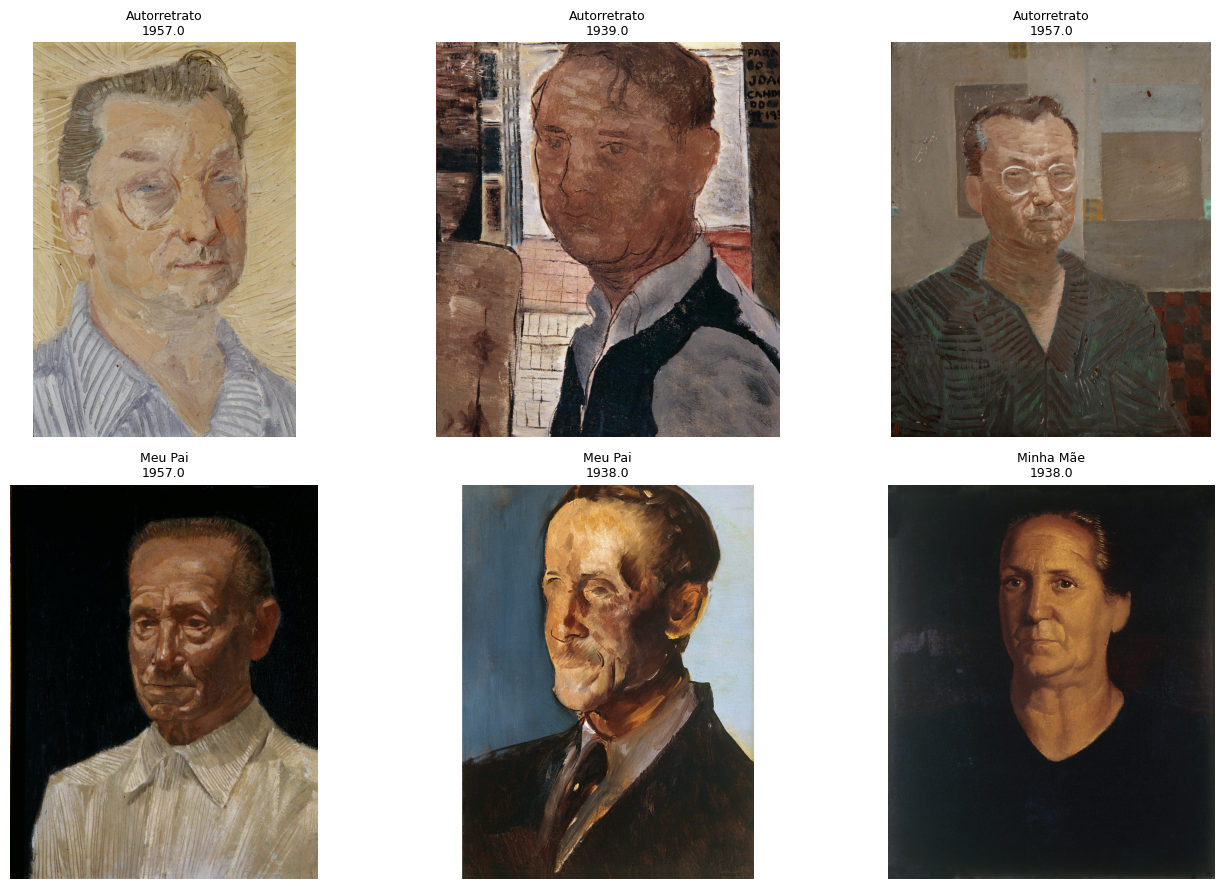

In [17]:
from IPython.display import display, Image as IPImage
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

pasta_imagens = Path('output/imagens')

# Pega até 6 obras que têm imagem salva
obras_com_imagem = df[df['imagemLocal'].notna()].head(6)

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()

for i, (_, obra) in enumerate(obras_com_imagem.iterrows()):
    caminho_img = pasta_imagens / obra['imagemLocal']
    if caminho_img.exists():
        img = mpimg.imread(caminho_img)
        axes[i].imshow(img)
        titulo = (obra['titulo'] or '')[:35]
        axes[i].set_title(f"{titulo}\n{obra.get('ano', '')}", fontsize=9)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## 8. Exportando para CSV e Excel

In [18]:
# CSV — fácil de abrir em qualquer lugar
df.to_csv('output/obras.csv', index=False, encoding='utf-8-sig')
print('✅ obras.csv salvo')

✅ obras.csv salvo


## 9. Salvando de volta em JSON (limpo)

In [19]:
# Converte o DataFrame de volta para lista de dicionários
obras_limpas = df.where(df.notna(), other=None).to_dict(orient='records')

with open('output/obras_limpo.json', 'w', encoding='utf-8') as f:
    json.dump(obras_limpas, f, ensure_ascii=False, indent=2)

print(f'✅ obras_limpo.json salvo com {len(obras_limpas)} registros')

✅ obras_limpo.json salvo com 1826 registros


In [20]:
# Identificar quais pinturas não tiveram imagem baixada
sem_imagem = df[df['imagemLocal'].isna()]
print(f'Obras sem imagem salva: {len(sem_imagem)}')
sem_imagem[['titulo', 'ano', 'tecnica']].head(20)

Obras sem imagem salva: 19


,titulo,ano,tecnica
850,Floresta,1960.0,técnica não identificada
1602,Retrato do Dr. I. F.,1922.0,técnica não identificada
1603,Retrato de Virgílio Francisco da Silva Filho,1923.0,técnica não identificada
1605,Retrato de Attílio M. Alves,1924.0,técnica não identificada
1606,Retrato de Maria Lydia,1924.0,técnica não identificada
1607,Retrato de Barbosa Lima Sobrinho,1926.0,técnica não identificada
1609,Retrato de Lucila Cerqueira César de Mesquita,1960.0,técnica não identificada
1610,Retrato de Arnaldo de Moraes,1932.0,técnica não identificada
1611,Retrato de Miguel Angel Cárcano,1934.0,técnica não identificada
1612,Retrato de Giuseppe Setti,1934.0,técnica não identificada
